Bu projede alışveriş merkezindeki müşteriler, gelir düzeyleri ve harcama skorlarına göre segmentlere ayrılmıştır. Projenin temel amacı, benzer müşteri davranışlarına sahip grupları belirleyerek müşteri analizi ve pazarlama stratejileri geliştirmektir. Veri seti üzerinde veri analizi, görselleştirme ve ölçeklendirme işlemleri uygulanmış, ardından KMeans Clustering algoritması kullanılarak müşteri segmentasyonu gerçekleştirilmiştir. Ayrıca Elbow Method ve Silhouette Score yöntemleri kullanılarak optimum cluster sayısı belirlenmiş ve müşteri kümeleri görselleştirilmiştir.

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


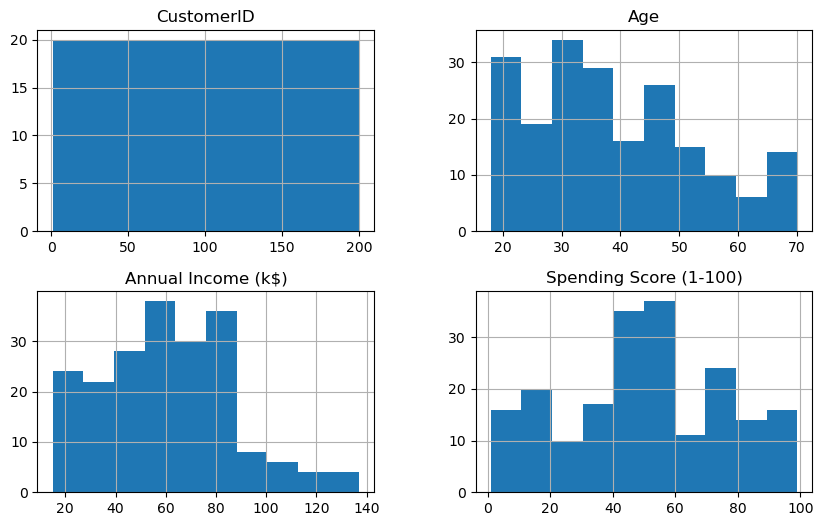

In [11]:
#Sayısal sütunların dağılımını inceliyoruz.
import matplotlib.pyplot as plt

df.hist(figsize=(10,6))

plt.show()

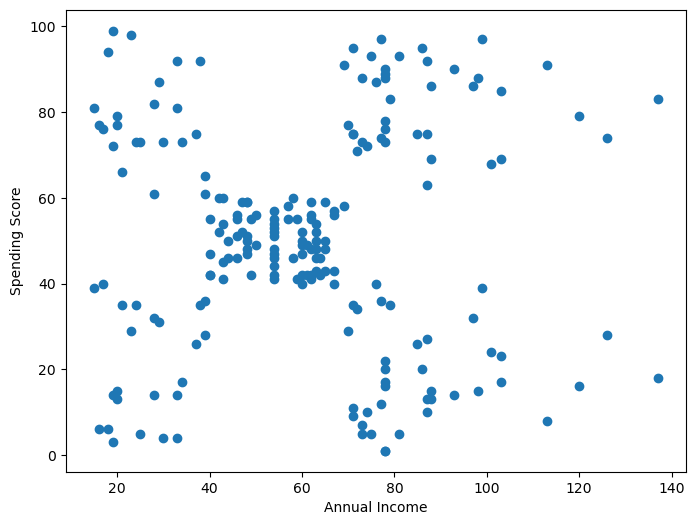

In [12]:
# Gelir ve harcama skorları arasındaki ilişkiye bakıyoruz.
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

In [14]:
#KMeans için en önemli iki feature’ı seçiyoruz.
x = df[["Annual Income (k$)", "Spending Score (1-100)"]]

x.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [15]:
# Verileri scale ediyoruz.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

x_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [16]:
# Elbow Method ile en uygun cluster sayısını buluyoruz.
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(x_scaled)

    wcss.append(kmeans.inertia_)

C:\Users\mehmet.sefer.kaya\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mehmet.sefer.kaya\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mehmet.sefer.kaya\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mehmet.sefer.kaya\AppData\Local\anaconda3\Lib\sit

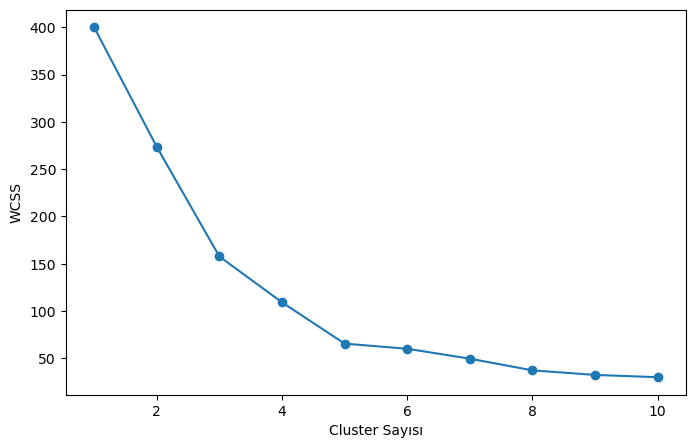

In [17]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Cluster Sayısı")
plt.ylabel("WCSS")

plt.show()

In [23]:
#pip install kneed

In [21]:
from kneed import KneeLocator

kl = KneeLocator(
    range(1, 11),
    wcss,
    curve="convex",
    direction="decreasing"
)

print("En uygun cluster sayısı:", kl.elbow)

En uygun cluster sayısı: 5


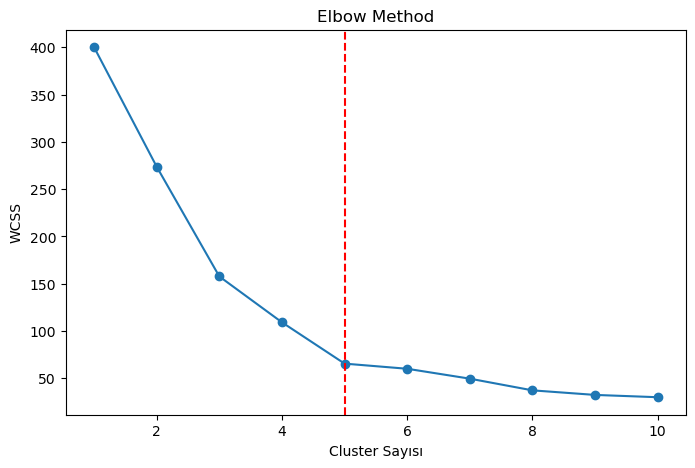

In [22]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.axvline(
    x=kl.elbow,
    color="red",
    linestyle="--"
)

plt.xlabel("Cluster Sayısı")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [24]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(x_scaled)

clusters

C:\Users\mehmet.sefer.kaya\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [25]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


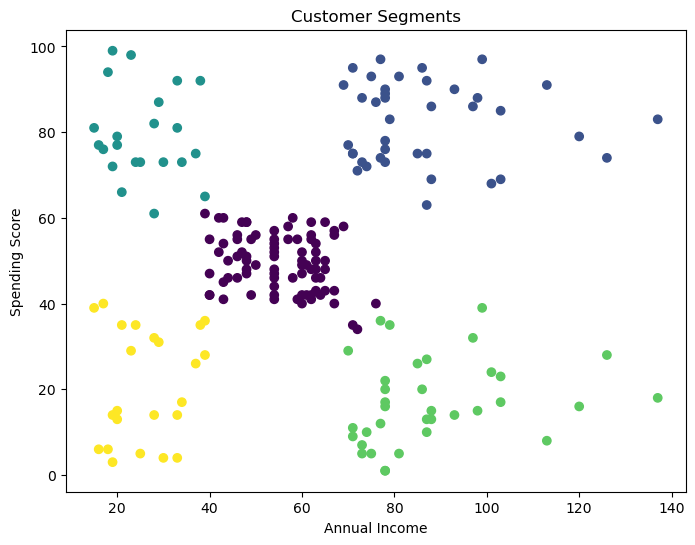

In [26]:
# Cluster sonuçlarını gelir ve harcama skoruna göre görselleştiriyoruz.
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")

plt.show()

In [28]:
df["Cluster"].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [30]:
# Clustering başarısını Silhouette Score ile ölçüyoruz.
from sklearn.metrics import silhouette_score

score = silhouette_score(x_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


In [32]:
import joblib

#KMeans modelini kaydediyoruz.
joblib.dump(kmeans,"kmeans_model.pkl")

['kmeans_model.pkl']

In [33]:
#Scaler nesnesini kaydediyoruz.
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

Proje sonucunda müşteriler farklı harcama davranışlarına göre başarılı şekilde kümelere ayrılmıştır. Özellikle yüksek gelir–yüksek harcama, yüksek gelir–düşük harcama ve düşük gelir–yüksek harcama gibi belirgin müşteri segmentleri ortaya çıkmıştır. KMeans Clustering algoritması ile elde edilen kümeler görselleştirilmiş ve Silhouette Score ile model performansı değerlendirilmiştir.